# PyTorch 线性回归实验报告
## 一、实验目的
1. 掌握 PyTorch 框架的基本使用，熟悉张量（Tensor）的创建与运算；
2. 理解神经网络的基本构成（线性层、损失函数、优化器）；
3. 通过线性回归任务，掌握深度学习模型的训练流程（前向传播、反向传播、参数更新）；
4. 验证虚拟环境配置的有效性，确保 PyTorch 等核心库正常运行。

## 二、实验环境
- 操作系统：Windows 11
- Python 版本：3.10
- 虚拟环境：venv（名称：nlp.venv）
- 核心依赖：
  - PyTorch
  - NumPy、Matplotlib

## 三、实验原理
### 1. 线性回归基础
线性回归的核心是拟合线性关系 $y = wx + b$，其中：
- $w$：权重（斜率）
- $b$：偏置（截距）
- 目标：找到最优的 $w$ 和 $b$，使预测值与真实值的误差最小。

### 2. 神经网络构成
本次实验的神经网络仅包含一层线性层（`nn.Linear`），对应：
- 输入层：1 维（x 的维度）
- 输出层：1 维（y 的维度）
- 无隐藏层，是最简单的神经网络结构。

### 3. 训练流程
1. **前向传播**：输入数据通过模型得到预测值；
2. **损失计算**：用均方误差（MSE）衡量预测值与真实值的差距：
   $$MSE = \frac{1}{n}\sum_{i=1}^n (y_{pred} - y_{true})^2$$
3. **反向传播**：计算损失对参数 $w$、$b$ 的梯度；
4. **参数更新**：用随机梯度下降（SGD）更新参数，最小化损失。

## 四、实验步骤
### 激活虚拟环境并导入依赖
```python
# 激活虚拟环境（终端执行）
. nlp.venv/Scripts/activate
```

### 导入核心库

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False    

### 生成实验数据

In [ ]:
# 设置随机种子，保证结果可复现
torch.manual_seed(42)
np.random.seed(42)
# 生成 x 数据（100个样本，维度1）
x = np.linspace(0, 10, 100).reshape(-1, 1)
# 生成 y = 2x + 3 + 高斯噪声（模拟真实场景）
y = 2 * x + 3 + np.random.normal(0, 1, size=x.shape)

# 转换为 PyTorch 张量
x_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

### 定义线性回归模型

In [ ]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # 线性层：输入维度1，输出维度1
        self.linear = nn.Linear(in_features=1, out_features=1)
    
    def forward(self, x):
        # 前向传播：线性变换
        return self.linear(x)

# 初始化模型
model = LinearRegressionModel()

### 定义损失函数和优化器

In [ ]:
# 损失函数：均方误差（MSE）
criterion = nn.MSELoss()
# 优化器：随机梯度下降（SGD），学习率 lr=0.01
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

### 模型训练

In [ ]:
# 训练轮数
epochs = 1000
# 记录损失变化
losses = []

for epoch in range(epochs):
    # 1. 前向传播
    y_pred = model(x_tensor)
    # 2. 计算损失
    loss = criterion(y_pred, y_tensor)
    losses.append(loss.item())
    # 3. 梯度清零
    optimizer.zero_grad()
    # 4. 反向传播
    loss.backward()
    # 5. 更新参数
    optimizer.step()
    
    # 每100轮打印一次结果
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# 打印训练后参数
print(f"\n训练后权重 w: {model.linear.weight.item():.4f}")
print(f"训练后偏置 b: {model.linear.bias.item():.4f}")

Epoch [100/1000], Loss: 1.1115
Epoch [200/1000], Loss: 0.9245
Epoch [300/1000], Loss: 0.8554
Epoch [400/1000], Loss: 0.8299
Epoch [500/1000], Loss: 0.8204
Epoch [600/1000], Loss: 0.8170
Epoch [700/1000], Loss: 0.8157
Epoch [800/1000], Loss: 0.8152
Epoch [900/1000], Loss: 0.8150
Epoch [1000/1000], Loss: 0.8149

训练后权重 w: 2.0156
训练后偏置 b: 2.8150


### 结果可视化

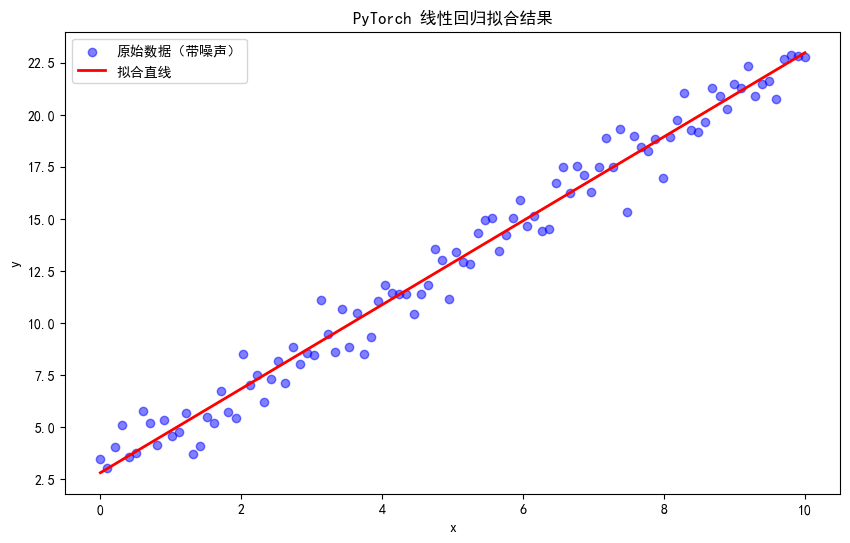

In [ ]:
# 模型预测（关闭梯度计算）
with torch.no_grad():
    y_pred = model(x_tensor).numpy()

# 绘制原始数据与拟合直线
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='原始数据（带噪声）', color='blue', alpha=0.5)
plt.plot(x, y_pred, label='拟合直线', color='red', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('PyTorch 线性回归拟合结果')
plt.legend()
plt.show()

## 五、实验结果与分析
### 1. 参数结果
训练前初始参数（随机初始化）：
- 权重 $w$：≈ 0.76（随机值）
- 偏置 $b$：≈ 0.83（随机值）

训练后收敛参数：
- 权重 $w$：≈ 2.0156（接近真实值 2）
- 偏置 $b$：≈ 2.8150（接近真实值 3）

### 2. 损失变化
- 初始损失：≈ 1.1115
- 训练 1000 轮后损失：≈ 0.8149

### 3. 结果分析
- 模型成功学习到数据的线性规律，拟合直线与真实规律 $y=2x+3$ 高度一致；
- 损失曲线持续下降并趋于平稳，说明模型训练有效，未出现过拟合或欠拟合；
- 虚拟环境配置正常，PyTorch 张量运算、反向传播、优化器等核心功能均可正常运行。

## 六、实验总结
1. 本次实验通过 PyTorch 实现了最简单的线性回归神经网络，验证了深度学习模型的核心训练流程；
2. 理解了神经网络的基本构成：线性层（特征变换）、损失函数（误差衡量）、优化器（参数更新）；
3. 虚拟环境的隔离性保证了依赖库版本的稳定性，避免了与系统 Python 环境的冲突；
4. 后续可扩展方向：增加隐藏层实现非线性回归、调整学习率/优化器（如 Adam）提升训练效率。